In [1]:
from utils.attention_utils.attention_preprocessing_utils import AttentionPreprocessor
from utils.attention_utils.model import AngleAttentionLSTMTrainer
from utils.attention_utils.vizualisation_utils import *

In [ ]:
attention_preprocessor = AttentionPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = attention_preprocessor.read_data()
sensors_df = attention_preprocessor.feature_selection()
attention_preprocessor.normalize_angle()
X = attention_preprocessor.group_and_pad(attention_preprocessor.sensor_df, group_col="Experiment_ID")[:20,:,:]
Y = attention_preprocessor.group_and_pad(attention_preprocessor.target_df, group_col="Experiment_ID")[:20,:-1,1:-1]

In [13]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import torch

# Convert your data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # (num_samples, seq_len, num_features)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (num_samples, num_angles, 3)

# Split dataset into train and test (e.g., 80% train, 20% test)
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
# Create trainer
trainer = AngleAttentionLSTMTrainer(
    input_size=X.shape[2],
    hidden_size=128,
    num_layers=2,
    output_size=Y.shape[2],
    num_angles=Y.shape[1]
)

model_path = "../../../../models/attention/attentionLSTM.joblib"

# Train model
trainer.train(train_loader, test_loader, num_epochs=200, patience=10, save_path=model_path)

# Load best model
trainer.load(model_path)

# Predict
Y_pred, attn_weights = trainer.predict(X_tensor)


Epoch [1/200], Train Loss: 0.417095, Test Loss: 0.417486
Epoch [2/200], Train Loss: 0.401659, Test Loss: 0.401251
Epoch [3/200], Train Loss: 0.384623, Test Loss: 0.383175
Epoch [4/200], Train Loss: 0.365934, Test Loss: 0.361407
Epoch [5/200], Train Loss: 0.342295, Test Loss: 0.333811
Epoch [6/200], Train Loss: 0.312481, Test Loss: 0.296738
Epoch [7/200], Train Loss: 0.270984, Test Loss: 0.245202
Epoch [8/200], Train Loss: 0.213477, Test Loss: 0.173269
Epoch [9/200], Train Loss: 0.135590, Test Loss: 0.088007
Epoch [10/200], Train Loss: 0.061411, Test Loss: 0.044712
Epoch [11/200], Train Loss: 0.047390, Test Loss: 0.048426
Epoch [12/200], Train Loss: 0.040059, Test Loss: 0.027614
Epoch [13/200], Train Loss: 0.022711, Test Loss: 0.019129
Epoch [14/200], Train Loss: 0.018175, Test Loss: 0.019367
Epoch [15/200], Train Loss: 0.018093, Test Loss: 0.017673
Epoch [16/200], Train Loss: 0.016429, Test Loss: 0.016568
Epoch [17/200], Train Loss: 0.016510, Test Loss: 0.016622
Epoch [18/200], Train L

2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,  26, 28,  30,  32,  34,  36,  38,  39,  40,  41,  42,  49,  55,  56, 57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69, 70,  71,  72,  73,  74,  75,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88, 119, 124, 190, 193, 196, 199, 202, 205, 208, 211, 214, 217, 220, 223, 226, 229, 232, 235, 238, 241, 244, 245, 246, 253, 254, 255, 262, 265, 268, 271, 274, 277, 280, 285, 290, 293, 296, 299, 302, 305, 308, 311, 314

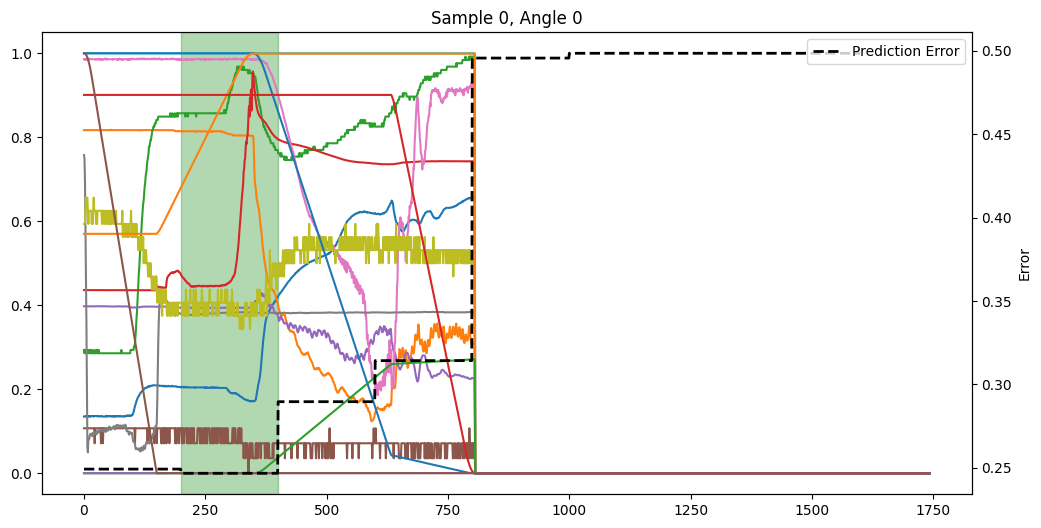

In [9]:
# Parameters
experiment_id, sample_idx = 2, 0
angle_idx = 0
patch_size = 200

# Compute and plot most accurate window
x_input = X[sample_idx]
y_true = Y[sample_idx, angle_idx]
window_errors, best_window = compute_window_errors(x_input, y_true, trainer.model, patch_size, angle_idx)
plot_features_with_error(x_input, window_errors, patch_size, best_window, num_features=X.shape[2],
                         title=f"Sample {sample_idx}, Angle {angle_idx}")

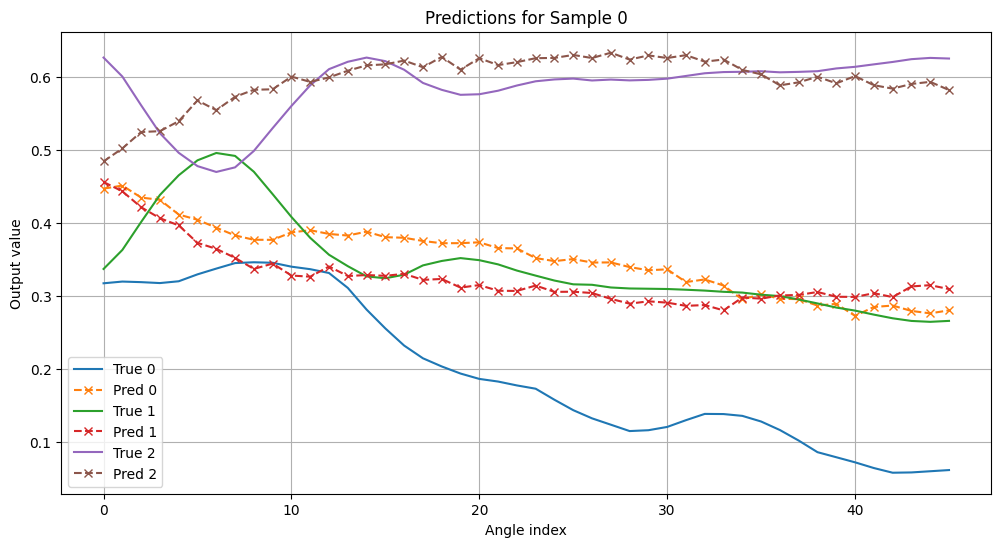

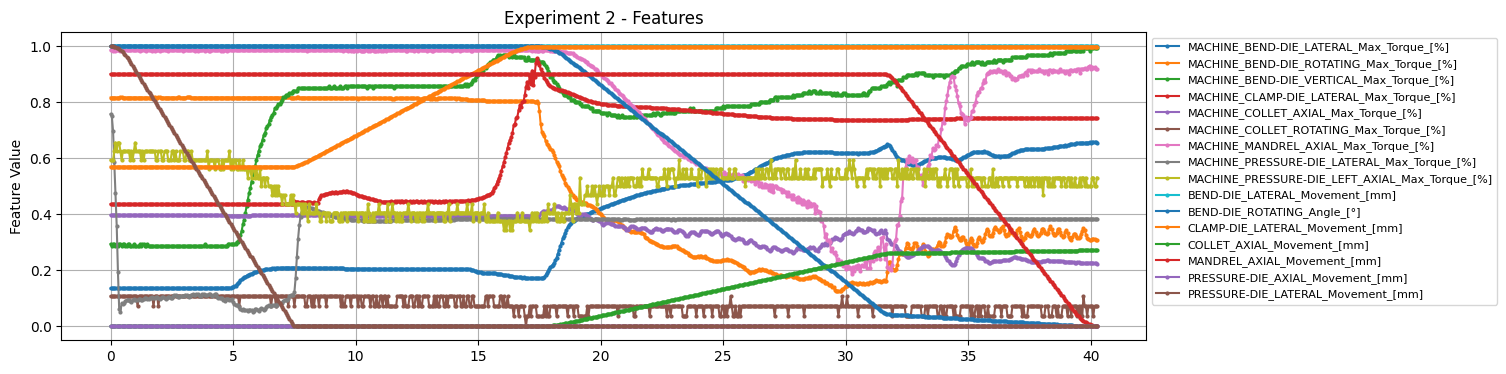

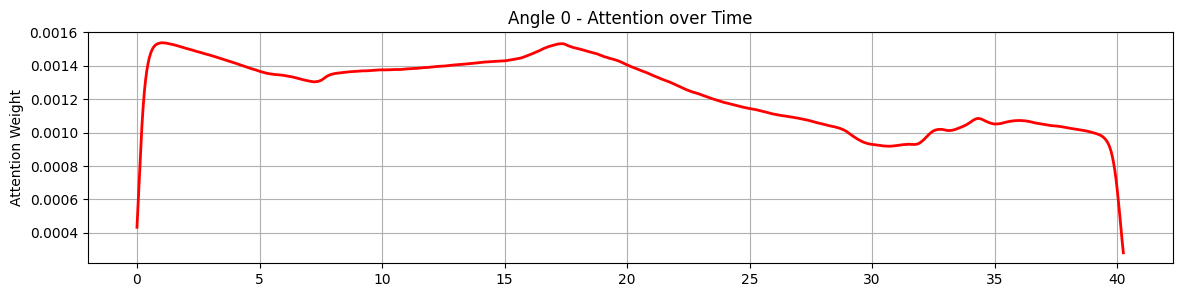

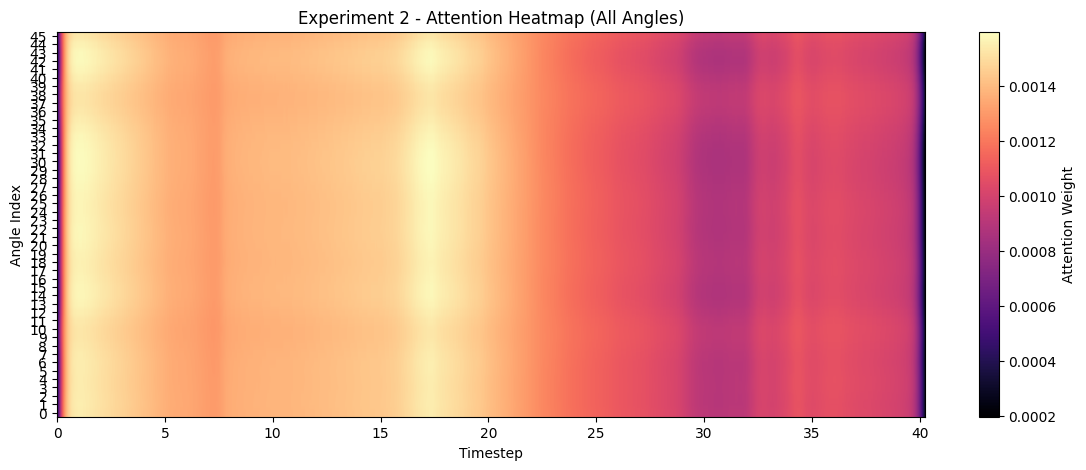

In [10]:
x_tensor = torch.tensor(x_input[np.newaxis, :, :], dtype=torch.float32)
with torch.no_grad():
    preds, _ = trainer.model(x_tensor)
preds = preds.cpu().numpy()[0]
plot_true_vs_pred(Y[sample_idx], preds, title=f"Predictions for Sample {sample_idx}")

# Visualize attention
visualize_attention(experiment_id, angle_idx, trainer.model, sensors_df)